# Import Environment variables

In [1]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [2]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Import library

In [3]:
%load_ext autoreload
%autoreload 2
    
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importation des données issues du notebook `54_Breast_Cancer_WITHIN_5Y_DataSelectionAndFiltering`

In [4]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory_LastSelection.tsv"

df = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)
df

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,Sibling,days_inclusion_to_first_survey,days_inclusion_to_last_survey,days_has_bc_to_first_survey,days_has_bc_to_last_survey,statut_parente,age_category,race_us_bcsc,race_us_bcsc_detail,breast_cancer_family_history_first_degree
0,1700611,Female,1949-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-09-17,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),72,2,afr_rye,0
1,1356439,Female,1949-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-03-04,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),67,3,eas_rye/sas_rye,0
2,3451057,Female,1951-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2023-01-18,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),72,3,eas_rye/sas_rye,0
3,1559161,Female,1951-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-03-11,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),67,8,amr_rye/mid_rye,0
4,1468526,Female,1956-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-10-07,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),62,1,eur_rye,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124896,4386725,Female,1982-06-15,Not Hispanic or Latino,White,2023-05-11,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0
124897,2743914,Female,1982-06-15,Not Hispanic or Latino,White,2022-08-08,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0
124898,1475516,Female,1982-06-15,Not Hispanic or Latino,White,2022-07-06,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0
124899,9915233,Female,1982-06-15,Not Hispanic or Latino,White,2022-09-14,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0


In [5]:
df.drop(columns=['gender','date_of_birth','ethnicity','self_reported_category','time_category','delay_years',
                 'first_any_biopsy_date','days_inclusion_to_biopsy', 'days_biopsy_to_cancer',
                 'first_survey_date', 'last_survey_date','days_last_survey_to_first_survey', 'days_inclusion_to_first_survey',
                 'days_inclusion_to_last_survey', 'days_has_bc_to_first_survey','days_has_bc_to_last_survey',
                 'date_1_of_biopsy_19081_19086', 'date_2_of_biopsy_19081_19086', 'date_3_of_biopsy_19081_19086',
                 'has_biopsy_19081_19086',
                 'date_1_of_biopsy_19100_19103', 'date_2_of_biopsy_19100_19103', 'date_3_of_biopsy_19100_19103',
                 'has_biopsy_19100_19103',
                 'date_1_of_biopsy_19120_19125_19126', 'date_2_of_biopsy_19120_19125_19126', 'date_3_of_biopsy_19120_19125_19126',
                 'has_biopsy_19120_19125_19126',
                 'Daughter', 'Mother', 'Sibling',
                 'statut_parente'], inplace=True)

In [6]:
df.columns

Index(['person_id', 'inclusion_date', 'first_breast_cancer_date', 'delay_days',
       'age_at_inclusion', 'has_bc', 'eur_rye', 'eas_rye', 'amr_rye',
       'afr_rye', 'sas_rye', 'mid_rye', 'dominant_origin', 'ancestry_80',
       'biopsy_result', 'age_category', 'race_us_bcsc', 'race_us_bcsc_detail',
       'breast_cancer_family_history_first_degree'],
      dtype='object')

# Selection des femmes européennes

In [7]:
df[df['race_us_bcsc_detail'] == 'eur_rye'].value_counts('has_bc')

has_bc
0    73120
1      464
Name: count, dtype: int64

In [8]:
df_eur = df[df['race_us_bcsc_detail'] == 'eur_rye'].copy()

# Calcul du score Mammorisk®

## Import Mammorisk®

In [9]:
pip install pycryptodome

Note: you may need to restart the kernel to use updated packages.


In [10]:
import getpass
import io
from Crypto.Cipher import AES
from Crypto.Protocol.KDF import PBKDF2

In [11]:
def load_encrypted_csv(enc_file_path, password):
    with open(enc_file_path, "rb") as f:
        salt = f.read(16)
        nonce = f.read(16)
        tag = f.read(16)
        ciphertext = f.read()

    # Dériver la même clé
    key = PBKDF2(password, salt, dkLen=32, count=100000)

    # Déchiffrer
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    decrypted_data = cipher.decrypt_and_verify(ciphertext, tag)

    # Charger directement dans Pandas via RAM
    return pd.read_csv(io.BytesIO(decrypted_data))

In [12]:
# Usage
my_encrypt_file= "Datas/mammorisk_encrypted_remi.enc"

password = getpass.getpass("Entrez le mot de passe MammoRisk : ")
df_mammorisk = load_encrypted_csv(my_encrypt_file, password)
print("✅ Fichier chargé en mémoire RAM ! Shape :", df_mammorisk.shape)

Entrez le mot de passe MammoRisk :  ········


✅ Fichier chargé en mémoire RAM ! Shape : (210, 5)


## Application du modèle Mammorisk®

In [13]:
df_eur.rename(columns={"biopsy_result": "biopsy"}, inplace=True)

In [14]:
# 1. Vérification/Harmonisation des noms de colonnes dans All of Us
# On s'assure que les colonnes de jointure ont des types identiques (int)
join_keys = [
    "age_category",
    "race_us_bcsc",
    "breast_cancer_family_history_first_degree",
    "biopsy",
]

# 2. Application de la jointure (merge) pour récupérer le score
df_Mammorisk = (df_eur.merge(df_mammorisk, on=join_keys, how="left"))

In [15]:
df_Mammorisk.rename(columns={"score_knn_v27_weighted_average_breast_density": "score_mammorisk"}, inplace=True)

In [16]:
# 4. Vérification de l'application
missing_scores = df_Mammorisk["score_mammorisk"].isna().sum()
print(f"Nombre d'individus avec un score MammoRisk attribué : {len(df_Mammorisk) - missing_scores}")
print(f"Nombre de scores manquants (échec de jointure) : {missing_scores}")

Nombre d'individus avec un score MammoRisk attribué : 73584
Nombre de scores manquants (échec de jointure) : 0


<Axes: ylabel='Frequency'>

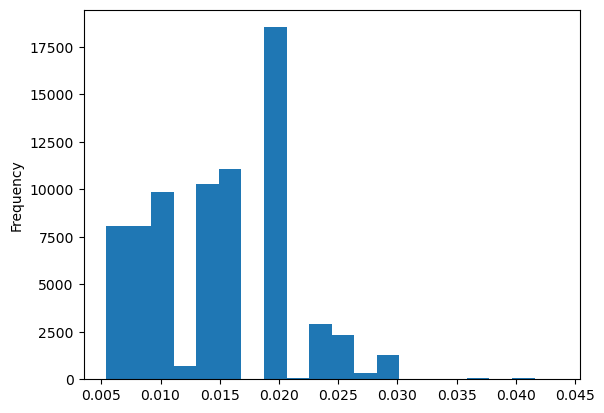

In [17]:
df_Mammorisk["score_mammorisk"].plot.hist(bins=20)

# Split de la cohorte européenne

In [18]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "train_ids_eur.csv"

train_ids_eur = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)

In [19]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "test_ids_eur.csv"

test_ids_eur = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)

# Evaluation de performance du modèle Mammorisk®

## Calcul du alpha recalibré sur le train set (25%)

In [20]:
import statsmodels.api as sm

# 3. Calcul de alpha sur le jeu TRAIN (25%)
df_train = df_Mammorisk[df_Mammorisk['person_id'].isin(list(train_ids_eur["person_id"]))].copy()

y_train = df_train["has_bc"]
p_train = np.clip(df_train["score_mammorisk"], 1e-6, 1.0 - 1e-6)
logit_p_train = np.log(p_train / (1.0 - p_train))

# Régression logistique avec Offset
X_train_const = np.ones((len(df_train), 1))
model_recalib = sm.Logit(y_train, X_train_const, offset=logit_p_train).fit(disp=False)

# Extraction de la constante de recalibration
alpha = model_recalib.params["const"]
print(f"Constante alpha estimée sur le Train (25%) : {alpha:.4f}")

Constante alpha estimée sur le Train (25%) : -0.8623


## Evaluation des models

### Définition de la fonction

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import auc, roc_curve


def bootstrap_auc(y_true_ser, y_scores_ser, n_bootstraps=1000, rng_seed=42):
    """Calcule l'intervalle de confiance à 95% de l'AUC-ROC par bootstrap."""
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    y_true_arr = np.array(y_true_ser)
    y_scores_arr = np.array(y_scores_ser)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_scores_arr), len(y_scores_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true_arr[indices], y_scores_arr[indices])[:2])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)
    return sorted_scores[int(0.025 * len(sorted_scores))], sorted_scores[
        int(0.975 * len(sorted_scores))
    ]


def evaluate_and_plot_model(
    df_data,
    test_ids,
    score_col,
    target_col="has_bc",
    alpha_val=0.0,
    id_col="person_id",
    model_name="BCSC v2",
    quantiles=None,
    labels=None,
    ref_quantile_idx=2,  # Par défaut Q3 (index 2 dans [Q1, Q2, Q3, Q4, Q5])
    figsize=(16, 6),
):
    """Évalue et trace les graphiques de discrimination (ROC) et de calibration (Incidence/OR)

    sur un jeu de test indépendant.
    """
    if quantiles is None:
        quantiles = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
    if labels is None:
        labels = [
            "Q1 (<20%)",
            "Q2 (20-40%)",
            "Q3 (40-60%)",
            "Q4 (60-80%)",
            "Q5 (>80%)",
        ]

    # 1. Sélection et nettoyage du Jeu de Test (75%)
    ids_to_match = (
        test_ids.values if hasattr(test_ids, "values") else list(test_ids)
    )
    df_test = df_data[df_data[id_col].isin(ids_to_match)].copy()
    df_eval = df_test.dropna(subset=[target_col, score_col]).copy()

    y_true = df_eval[target_col]
    p_brut = df_eval[score_col]

    # 2. Application de la recalibration d'intercept (alpha)
    p_clipped = np.clip(p_brut, 1e-6, 1.0 - 1e-6)
    logit_p = np.log(p_clipped / (1.0 - p_clipped))
    logit_p_recalib = logit_p + alpha_val
    p_recalib = 1.0 / (1.0 + np.exp(-logit_p_recalib))

    # Nom dynamique de la colonne recalibrée (ex: score_mammorisk_recalib)
    recalib_col_name = f"{score_col}_recalib"
    df_eval[recalib_col_name] = p_recalib

    # 3. Métriques ROC et AUC
    fpr, tpr, _ = roc_curve(y_true, p_recalib)
    roc_auc = auc(fpr, tpr)
    ci_lower, ci_upper = bootstrap_auc(y_true, p_recalib)

    # 4. Métriques O/E (Calibration globale)
    observed_cases = int(y_true.sum())
    expected_brut = float(p_brut.sum())
    expected_recalib = float(p_recalib.sum())

    oe_brut = observed_cases / expected_brut if expected_brut > 0 else np.nan
    oe_recalib = (
        observed_cases / expected_recalib if expected_recalib > 0 else np.nan
    )

    # 5. Découpage en Quantiles & Calculs par groupe
    df_eval["risk_group"] = pd.qcut(
        df_eval[recalib_col_name],
        q=quantiles,
        labels=labels,
        duplicates="drop",
    )

    # A. Incidence réelle (%)
    incidence = df_eval.groupby("risk_group", observed=False)[target_col].agg(
        ["mean", "count"]
    )
    incidence["pct"] = incidence["mean"] * 100
    incidence = incidence.reindex(labels)

    # B. Risque moyen prédit réétalonné (%)
    pred_risk = df_eval.groupby("risk_group", observed=False)[
        recalib_col_name
    ].mean()
    pred_risk_pct = (pred_risk * 100).reindex(labels)

    # C. Odds Ratios par régression logistique
    dummies = pd.get_dummies(df_eval["risk_group"], drop_first=False)

    ref_col = labels[ref_quantile_idx]
    if ref_col not in dummies.columns:
        ref_col = dummies.columns[len(dummies.columns) // 2]

    X = dummies.drop(columns=[ref_col]).astype(int)
    X = sm.add_constant(X)

    logit_mod = sm.Logit(y_true, X).fit(disp=False)
    conf = logit_mod.conf_int()

    or_df = pd.DataFrame(
        {
            "OR": np.exp(logit_mod.params),
            "lower": np.exp(conf[0]),
            "upper": np.exp(conf[1]),
        }
    )
    or_df.loc["const"] = [1.0, 1.0, 1.0]
    or_df.index = [c if c != "const" else ref_col for c in or_df.index]
    or_df = or_df.reindex(labels)

    # 6. Tracé de la Figure à 2 Panneaux
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- Subplot 1 : ROC & Cartouche O/E ---
    axes[0].plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=(
            f"{model_name} (AUC = {roc_auc:.3f} [IC 95% :"
            f" {ci_lower:.3f}-{ci_upper:.3f}])"
        ),
    )
    axes[0].plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--",
        label="Hasard (AUC = 0.50)",
    )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("1 - Spécificité (Taux Faux Positifs)", fontsize=10)
    axes[0].set_ylabel("Sensibilité (Taux Vrais Positifs)", fontsize=10)
    axes[0].set_title(
        f"Courbe ROC - Modèle {model_name} (Jeu Test N={len(df_eval)})",
        fontsize=11,
        fontweight="bold",
    )
    axes[0].legend(loc="lower right")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    text_str = (
        r"$\mathbf{Calibration\ globale\ (Test\ 75\%):}$"
        "\n"
        rf"• $\mathbf{{Cas\ observés\ (O)\ :}}$ {observed_cases}"
        "\n\n"
        r"$\mathbf{1.\ Modèle\ Brut:}$"
        "\n"
        rf"• Cas attendus (E) : {expected_brut:.1f}"
        "\n"
        rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_brut:.3f}"
        "\n\n"
        rf"$\mathbf{{2.\ Modèle\ Recalibré\ (\alpha = {alpha_val:.4f}):}}$"
        "\n"
        rf"• Cas attendus (E) : {expected_recalib:.1f}"
        "\n"
        rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_recalib:.3f}"
    )

    axes[0].text(
        0.04,
        0.96,
        text_str,
        transform=axes[0].transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9,
        ),
    )

    # --- Subplot 2 : Barres d'Incidence/Risque Prédit + OR ---
    x_pos = np.arange(len(labels))

    axes[1].bar(
        x_pos - 0.15,
        incidence["pct"],
        width=0.3,
        alpha=0.6,
        color="skyblue",
        edgecolor="navy",
        label="Incidence réelle (%)",
    )

    axes[1].bar(
        x_pos + 0.15,
        pred_risk_pct,
        width=0.3,
        alpha=0.6,
        color="orange",
        edgecolor="darkorange",
        label="Risque prédit réétalonné (%)",
    )

    axes[1].set_xlabel("Quantiles de risque", fontsize=10)
    axes[1].set_ylabel(
        "Pourcentage (%)", fontsize=10, color="navy", fontweight="bold"
    )
    axes[1].tick_params(axis="y", labelcolor="navy")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(labels, rotation=30)
    axes[1].grid(True, linestyle=":", alpha=0.4)

    ax2 = axes[1].twinx()
    valid_or = or_df.dropna(subset=["OR"])
    valid_x = [labels.index(idx) for idx in valid_or.index if idx in labels]

    line_or = ax2.errorbar(
        valid_x,
        valid_or["OR"],
        yerr=[
            valid_or["OR"] - valid_or["lower"],
            valid_or["upper"] - valid_or["OR"],
        ],
        fmt="o-",
        color="darkred",
        ecolor="crimson",
        elinewidth=1.8,
        capsize=4,
        markersize=6,
        label="Odds Ratio (IC 95%)",
    )

    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
    ax2.set_ylabel(
        f"Odds Ratio (OR) vs Quantile Médian ({ref_col})",
        fontsize=10,
        color="darkred",
        fontweight="bold",
    )
    ax2.tick_params(axis="y", labelcolor="darkred")

    lines_1, labels_1 = axes[1].get_legend_handles_labels()
    axes[1].legend(
        lines_1 + [line_or],
        labels_1 + ["Odds Ratio (IC 95%)"],
        loc="upper left",
        frameon=True,
        fontsize=8.5,
    )

    axes[1].set_title(
        f"Incidence, Risque prédit et Odds Ratios par quantile ({model_name})",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

    # Dictionnaire des métriques
    metrics = {
        "AUC": roc_auc,
        "AUC_CI": (ci_lower, ci_upper),
        "OE_brut": oe_brut,
        "OE_recalib": oe_recalib,
        "alpha": alpha_val,
        "N_test": len(df_eval),
    }

    # La fonction retourne DEUX objets : le dictionnaire et le DataFrame
    return metrics, df_eval

### Evaluation du model Mammorisk

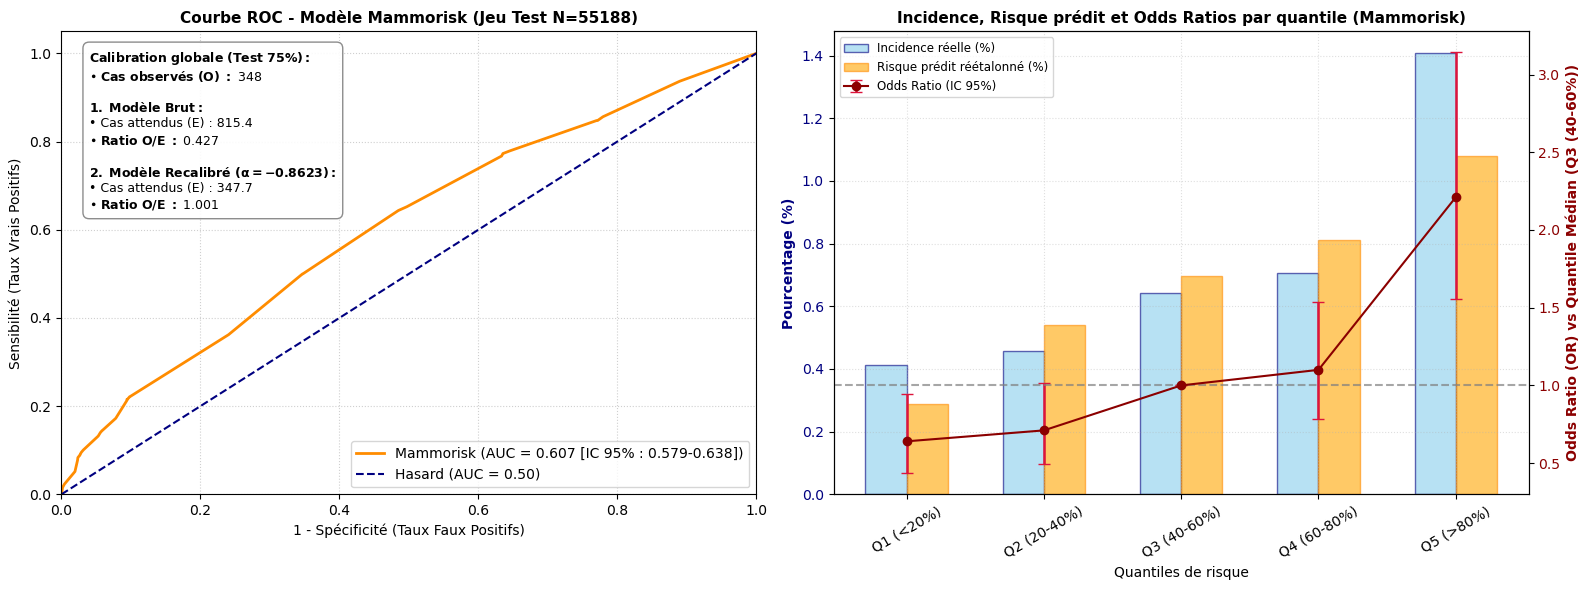

In [22]:
# Exemple pour Mammorisk
metrics_mammo, df_mammo_eval = evaluate_and_plot_model(
    df_data=df_Mammorisk,
    test_ids=test_ids_eur["person_id"],
    score_col="score_mammorisk",
    target_col="has_bc",
    alpha_val=alpha,  # L'alpha spécifique calculé sur le Train pour Mammorisk
    model_name="Mammorisk",
)

1. **AUC-ROC (Area Under the ROC Curve) :** Évalue la capacité globale de discrimination.
    * **Si l'AUC est comprise entre $0,60$ et $0,68$ :** C'est la performance clinique standard attendue pour les modèles épidémiologiques de première génération (BCSC, Gail, Tyrer-Cuzick sans génétique ni densité). Dans l'article d'Elie Rassy et al., les scores cliniques seuls se situent exactement dans cette zone avant l'ajout du score de risque polygénique (PRS).
3. **Courbe ROC :** Visualisation du compromis entre sensibilité et spécificité.
4. **Courbe de Calibration :** Compare le risque moyen prédit au taux de cancer réel par décile de risque.
5. **Ratio O/E (Observed / Expected) :** Évalue la sur-estimation ou sous-estimation globale du modèle.
    * Interprétation du Ratio O/E :
      * $\text{O/E} \approx 1,0$ : Le modèle est parfaitement calibré sur la cohorte.
      * $\text{O/E} < 1,0$ : Le modèle sur-estime le risque réel dans All of Us.
      * $\text{O/E} > 1,0$ : Le modèle sous-estime le risque.

# Data's export

In [23]:
destination_filename = 'Datas/df_test_eur_Mammorisk_recalib.tsv'
df_mammo_eval.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./Datas/df_test_eur_Mammorisk_recalib.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 10.8 MiB]                                                \r/ [1 files][ 10.8 MiB/ 10.8 MiB]                                                \r\nOperation completed over 1 objects/10.8 MiB.                                     \n'